# Real Data Example

This notebook demonstrates a practical end-to-end **Diversifind** workflow on
real market data.

We will:

1. Load aligned close prices from a CSV file
2. Compute daily returns
3. Build the correlation matrix
4. Run diversification search
5. Inspect the best portfolio
6. Analyze the result

The input data used here is:

- `examples/data/sample_closes.csv`

## 1. Imports

Import the libraries needed for working with price data, building correlations,
and running Diversifind.

In [50]:
import pandas as pd

from diversifind import beam, greedy, analyze_portfolio, top_abs_corr_pairs


## 2. Load Close Price Data

Load the aligned close-price matrix from CSV.

Suggested checks:

- inspect the first few rows
- confirm the shape
- confirm the index is parsed as dates

In [51]:
closes = pd.read_csv('data/sample_closes.csv', index_col=0, parse_dates=True)
print("Shape:", closes.shape)
print("Index type:", type(closes.index))
print("Date range:", closes.index.min(), "->", closes.index.max())
print("Number of symbols:", len(closes.columns))
print(closes.head())

Shape: (1032, 163)
Index type: <class 'pandas.DatetimeIndex'>
Date range: 2022-02-01 00:00:00 -> 2026-02-20 00:00:00
Number of symbols: 163
              AAPL    ABBV     ABT     ADI     AGG    AMAT     AMD    AMGN  \
date                                                                         
2022-02-01  174.61  137.00  127.20  165.37  111.60  138.61  116.78  228.68   
2022-02-02  175.84  138.62  130.04  168.91  111.72  140.76  122.76  228.93   
2022-02-03  172.90  140.73  130.11  162.02  111.27  136.51  120.08  224.04   
2022-02-04  172.39  140.65  129.71  161.03  110.57  135.57  123.60  222.11   
2022-02-07  171.66  142.53  128.05  160.82  110.67  136.13  123.67  223.53   

                AMZN    ANET  ...    XLE    XLF     XLI     XLK    XLP   XLRE  \
date                          ...                                               
2022-02-01  151.1935  124.30  ...  68.27  39.60  102.13  162.39  75.90  47.02   
2022-02-02  150.6125  125.61  ...  68.49  39.87  102.84  163.71  76.81

## 3. Convert Prices to Returns

Convert close prices into daily percentage returns.

Suggested checks:

- inspect the first few rows of returns
- verify missing values are handled appropriately
- compare price shape vs return shape

Note: the 163 missing values are expected because each of the 163 assets loses one first return observation.

In [52]:
returns = closes.pct_change()

print("Total missing values:", returns.isna().sum().sum())
print("Missing values per column (first 5):")
print(returns.isna().sum().head())

returns = returns.dropna()

print("Return matrix shape:", returns.shape)
print("Remaining NaNs:", returns.isna().sum().sum())

Total missing values: 163
Missing values per column (first 5):
AAPL    1
ABBV    1
ABT     1
ADI     1
AGG     1
dtype: int64
Return matrix shape: (1031, 163)
Remaining NaNs: 0


## 4. Build the Correlation Matrix

Construct the correlation matrix from the return series.

Suggested checks:

- inspect the matrix shape
- confirm the symbol ordering
- optionally view the correlation matrix as a DataFrame

In [53]:
symbols = returns.columns.tolist()

corr_df = returns.corr()
corr = corr_df.to_numpy()

print("Correlation matrix shape:", corr.shape)
print("Number of symbols:", len(symbols))

corr_df.iloc[:5, :5]

Correlation matrix shape: (163, 163)
Number of symbols: 163


,AAPL,ABBV,ABT,ADI,AGG
AAPL,1.000000,0.133583,0.293796,0.563378,0.172521
ABBV,0.133583,1.000000,0.330738,0.158036,0.097239
ABT,0.293796,0.330738,1.000000,0.298965,0.168417
ADI,0.563378,0.158036,0.298965,1.000000,0.158271
AGG,0.172521,0.097239,0.168417,0.158271,1.000000


## 5. Run Diversification Search

Run a search method such as `beam` on the correlation matrix.

Suggested parameters to start with:

- `k = 8`
- `beam_width = 500`
- `top_k = 5`

In [54]:
result = beam(corr, symbols, k=8, beam_width=500, top_k=5)

## 6. Inspect the Search Results

Use the result object's built-in helpers to inspect the portfolios.

Suggested things to show:

- `result.pretty()`
- `result.best()`
- the selected symbols of the best portfolio

In [55]:
print(result.pretty(), '\n')
best = result.best()
print("Best portfolio symbols:", best.combo_symbols)
print("Best portfolio logdet:", best.logdet)

Method: beam
Portfolio size: 8
Returned results: 5
beam_width: 500

Top diversified portfolios:

Rank      LogDet  Symbols
-------------------------
   1   -0.046403  BABA, GLDM, HDB, LLY, SGOV, TLT, UNG, UNH
   2   -0.046512  GLDM, HDB, LLY, PDD, SGOV, TLT, UNG, UNH
   3   -0.046837  GLDM, LLY, PDD, SCHD, SGOV, TLT, UNG, UNH
   4   -0.048131  BIL, GLDM, HDB, LLY, PDD, TLT, UNG, UNH
   5   -0.048263  GLDM, HDB, JAAA, LLY, PDD, TLT, UNG, UNH 

Best portfolio symbols: ['BABA', 'GLDM', 'HDB', 'LLY', 'SGOV', 'TLT', 'UNG', 'UNH']
Best portfolio logdet: -0.046403474358870524


## 7. Analyze the Best Portfolio

Use the analytics helpers to understand *why* the selected portfolio is
well-diversified.

Suggested diagnostics:

- effective rank
- max absolute correlation
- mean absolute correlation
- min eigenvalue
- strongest pairwise correlations inside the portfolio

In [56]:
analysis = analyze_portfolio(
    corr=corr,
    combo=result.best().combo_indices,
    symbols=symbols,
)

print("Best portfolio analytics:")
print(f"LogDet: {analysis['logdet']:.6f}")
print(f"Effective rank: {analysis['effective_rank']:.4f}")
print(f"Mean absolute correlation: {analysis['mean_abs_corr']:.4f}")
print(f"Max absolute correlation: {analysis['max_abs_corr']:.4f}")
print(f"Min eigenvalue: {analysis['min_eigenvalue']:.4f}")
print(f"Max eigenvalue: {analysis['max_eigenvalue']:.4f}")
print()

pairs = top_abs_corr_pairs(
    corr=corr,
    combo=result.best().combo_indices,
    symbols=symbols,
    top_m=3,
)

print("Strongest correlation pairs inside the best portfolio:")
for row in pairs:
    print(f"{row['pair_symbols'][0]} -- {row['pair_symbols'][1]} | |corr|={row['abs_corr']:.4f}")

Best portfolio analytics:
LogDet: -0.046403
Effective rank: 7.9531
Mean absolute correlation: 0.0293
Max absolute correlation: 0.1115
Min eigenvalue: 0.8368
Max eigenvalue: 1.2335

Strongest correlation pairs inside the best portfolio:
BABA -- HDB | |corr|=0.1115
LLY -- UNH | |corr|=0.1092
HDB -- LLY | |corr|=0.0821


## 8. Optional Comparisons

Optional extensions you may want to try:

- compare `beam` vs `greedy`
- change `k`
- change `beam_width`
- inspect more than one ranked portfolio

In [57]:
# Compare beam vs greedy on the same universe
greedy_result = greedy(corr, symbols, k=8)

print("Beam search results:")
print(result.pretty())

print("\nGreedy search results:")
print(greedy_result.pretty())

print("\nBest beam portfolio:")
print(result.best())

print("\nBest greedy portfolio:")
print(greedy_result.best())

Beam search results:
Method: beam
Portfolio size: 8
Returned results: 5
beam_width: 500

Top diversified portfolios:

Rank      LogDet  Symbols
-------------------------
   1   -0.046403  BABA, GLDM, HDB, LLY, SGOV, TLT, UNG, UNH
   2   -0.046512  GLDM, HDB, LLY, PDD, SGOV, TLT, UNG, UNH
   3   -0.046837  GLDM, LLY, PDD, SCHD, SGOV, TLT, UNG, UNH
   4   -0.048131  BIL, GLDM, HDB, LLY, PDD, TLT, UNG, UNH
   5   -0.048263  GLDM, HDB, JAAA, LLY, PDD, TLT, UNG, UNH

Greedy search results:
Method: greedy
Portfolio size: 8
Returned results: 1

Top diversified portfolios:

Rank      LogDet  Symbols
-------------------------
   1   -0.075827  GILD, GLDM, HDB, NVDA, SGOV, TLT, UNG, UNH

Best beam portfolio:
PortfolioEntry(rank=1, logdet=-0.046403474358870524, combo_indices=[16, 47, 53, 78, 117, 127, 136, 137], combo_symbols=['BABA', 'GLDM', 'HDB', 'LLY', 'SGOV', 'TLT', 'UNG', 'UNH'])

Best greedy portfolio:
PortfolioEntry(rank=1, logdet=-0.07582735755135483, combo_indices=[45, 47, 53, 92, 117, 

## 9. Takeaways

Using a universe of 163 liquid instruments, Diversifind identifies portfolios whose return streams are nearly independent.

The best portfolio found by beam search was:

BABA, GLDM, HDB, LLY, SGOV, TLT, UNG, UNH

Several properties stand out:

- **Very low internal correlation**
  Mean absolute correlation is only about **0.03**, with the strongest pair around **0.11**.

- **Near-maximum effective rank**
  The effective rank of the portfolio correlation matrix is **~7.95 out of 8**, indicating that almost every asset contributes an independent dimension of return.

- **Economically intuitive diversification**
  The portfolio mixes exposures across commodities, bonds, healthcare, financials, and international equities.

Comparing search methods also highlights the advantage of beam search: it discovers a significantly better diversified portfolio than greedy search, which tends to get stuck in locally optimal choices.

Overall, this example shows how Diversifind can efficiently discover highly diversified portfolios even within large asset universes.

 ## 10. Visualizing Portfolio Correlations

 To better understand the diversification structure of the selected portfolio,
 we can visualize the correlation matrix of the chosen assets.

 A well-diversified portfolio should show correlations that are mostly small in
 magnitude and not clustered around a single factor.

 The heatmap below displays the correlation structure of the best portfolio
 identified by the search.

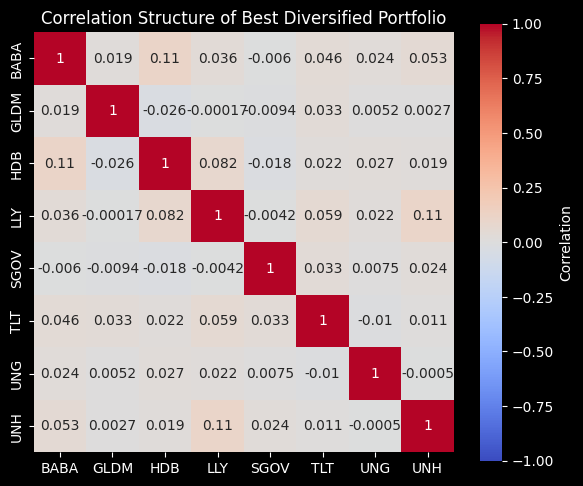

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns

best = result.best()
best_symbols = best.combo_symbols

# Extract correlation submatrix
sub_corr = corr_df.loc[best_symbols, best_symbols]

plt.figure(figsize=(6, 5))
sns.heatmap(
    sub_corr,
    annot=True,
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    cbar_kws={"label": "Correlation"},
)

plt.title("Correlation Structure of Best Diversified Portfolio")
plt.tight_layout()
plt.show()

## 11. Eigenvalue Spectrum

Another way to understand diversification is through the eigenvalues of the
portfolio correlation matrix.

If the portfolio assets are perfectly independent, all eigenvalues would be 1.
In practice we look for a spectrum that is **well spread and not dominated by
a single large factor**.

The plot below shows the eigenvalues of the selected portfolio.

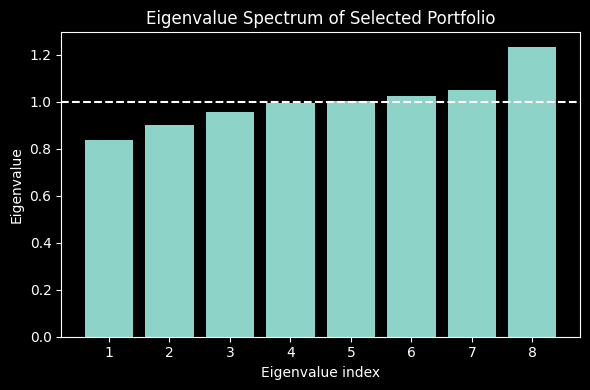

In [59]:
import numpy as np

eigvals = np.linalg.eigvalsh(sub_corr)

plt.figure(figsize=(6,4))
plt.bar(range(1, len(eigvals)+1), eigvals)

plt.axhline(1, linestyle="--")

plt.xlabel("Eigenvalue index")
plt.ylabel("Eigenvalue")
plt.title("Eigenvalue Spectrum of Selected Portfolio")

plt.tight_layout()
plt.show()